# 01 - Quantum states and normalization

Minimal hands-on companion to the theory (full treatment: README and notebook 13).
A pure state |psi> = (c_0, ..., c_{d-1}) is physically valid iff
sum |c_i|^2 = 1 (Born rule consistency).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from qsv.data_generation import generate_valid_states, verify_normalization

# A hand-built state: (1, 1)/sqrt(2) is the balanced superposition
raw = np.array([[1.0 + 0j, 1.0 + 0j]])
norm = np.linalg.norm(raw)
state = raw / norm
ok, norms_sq = verify_normalization(state)
print(f"raw norm^2 = {np.sum(np.abs(raw)**2):.3f} -> normalized: {ok}, norm^2 = {norms_sq[0]:.12f}")

raw norm^2 = 2.000 -> normalized: True, norm^2 = 1.000000000000


In [2]:
# Haar-random valid states: gaussian draw + normalization
states = generate_valid_states(1000, dim=4, strategy="random", seed=42)
ok, norms_sq = verify_normalization(states)
print(f"1000 random states, all normalized: {ok}")
print(f"max |norm^2 - 1| = {np.abs(norms_sq - 1).max():.2e}  (float64 rounding)")

1000 random states, all normalized: True
max |norm^2 - 1| = 6.66e-16  (float64 rounding)


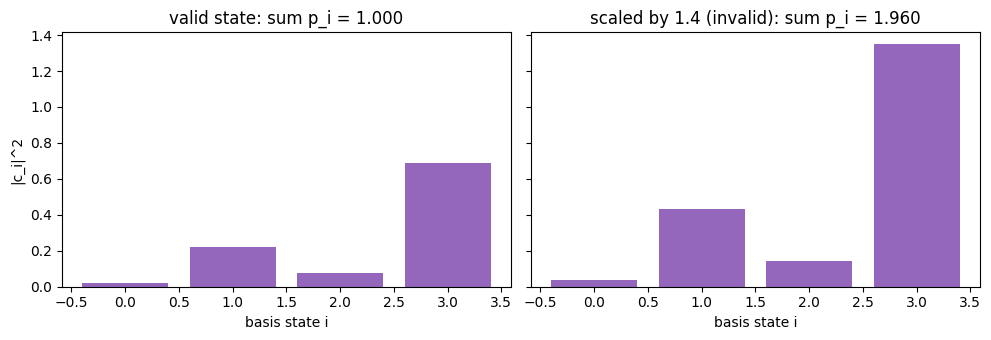

In [3]:
# Born probabilities of one state, valid vs scaled-invalid
psi = states[0]
bad = 1.4 * psi  # gain error: same direction, wrong norm

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, s, title in [(axes[0], psi, "valid state"), (axes[1], bad, "scaled by 1.4 (invalid)")]:
    p = np.abs(s) ** 2
    ax.bar(range(len(p)), p, color="tab:purple")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{title}: sum p_i = {p.sum():.3f}")
    ax.set_xlabel("basis state i")
axes[0].set_ylabel("|c_i|^2")
plt.tight_layout(); plt.show()

The scaled state keeps the same *shape* of probabilities but their sum is 1.96,
not 1 - the norm is the only thing that distinguishes it. That single observation
drives the whole project (notebooks 07-12).